# E.R.M.E.S. - Fase 2: Data Pipeline e Class Weights

Alla luce dell'Analisi Esplorativa (EDA), in questa fase prepariamo i dati per il training della CNN strutturando le contromisure necessarie per i bias riscontrati. 
Utilizzeremo le API moderne di TensorFlow (`tf.data`) per:
1. Caricamento ottimizzato in memoria tramite Dataset, forzando la conversione in Grayscale (come emerso dall'analisi di integrità).
2. Definizione della Data Augmentation per compensare l'alto rumore strutturale e il disallineamento dei volti.
3. Calcolo matematico dei pesi per bilanciare la Loss Function in risposta allo sbilanciamento (rapporto 16:1 tra Happy e Disgust).

In [1]:
"""
Configurazione iniziale e verifica dell'ambiente di calcolo.
Importazione delle librerie necessarie per la gestione dei percorsi,
operazioni tensoriali e calcolo statistico dei pesi.
"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from typing import Tuple, Dict

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2.1 Caricamento Dati e Ottimizzazione I/O
Creazione dei dataset iterabili. Impostiamo `color_mode='grayscale'` per eliminare i canali RGB ridondanti. Applichiamo `cache()` e `prefetch()` per evitare colli di bottiglia durante l'invio dei tensori alla GPU.

In [2]:
train_dir = Path('../data/fer2013/train')
test_dir = Path('../data/fer2013/test')

BATCH_SIZE = 64
IMG_SIZE = (48, 48)

def create_datasets() -> Tuple[tf.data.Dataset, tf.data.Dataset]:
    """
    Inizializza e ottimizza i dataset di Training e Validation.
    
    Returns:
        Tuple[tf.data.Dataset, tf.data.Dataset]: Dataset di addestramento e validazione.
    """
    print("Inizializzazione Training Dataset...")
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        color_mode='grayscale', # Riduzione dimensionale come da EDA
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        label_mode='int'        # Etichette come interi da 0 a 6
    )

    print("\nInizializzazione Validation Dataset...")
    val_dataset = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        color_mode='grayscale',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        label_mode='int'
    )

    # Cache e Prefetching per parallelizzare CPU e GPU
    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
    val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
    
    return train_dataset, val_dataset

train_ds, val_ds = create_datasets()

Inizializzazione Training Dataset...
Found 28709 files belonging to 7 classes.

Inizializzazione Validation Dataset...
Found 7178 files belonging to 7 classes.


## 2.2 Pipeline di Data Augmentation e Normalizzazione

In risposta al basso Face Detection Rate e alla sfocatura geometrica dei volti medi emersa nell'EDA, introduciamo traslazioni, rotazioni e zoom casuali. Includiamo anche il Rescaling per normalizzare le forti disparità di illuminazione.

In [3]:
"""
Definizione del blocco sequenziale di trasformazione visiva.
Questo layer verrà integrato direttamente all'inizio della rete neurale,
garantendo che le trasformazioni avvengano a livello di tensore.
"""

data_augmentation = tf.keras.Sequential([
    # Converte i pixel da [0, 255] a [0.0, 1.0] per normalizzare l'illuminazione.
    # Compensa le disparità statistiche rilevate tra le classi
    tf.keras.layers.Rescaling(1./255),
    
    # Trasformazioni spaziali per indurre invarianza locale e 
    # compensare il disallineamento geometrico dei volti
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
], name="data_augmentation_block")

print("Blocco di Data Augmentation e Rescaling definito con successo.")

Blocco di Data Augmentation e Rescaling definito con successo.


## 2.3 Bilanciamento delle Classi

Per contrastare il bias verso la classe maggioritaria (Happy), calcoliamo i pesi inversamente proporzionali alla frequenza di ciascuna classe. Questi pesi moltiplicheranno il valore della Loss Function durante la backpropagation.

In [4]:
def calculate_class_weights(dataset: tf.data.Dataset) -> Dict[int, float]:
    """
    Estrae le etichette dal dataset e calcola i pesi bilanciati.
    
    Args:
        dataset (tf.data.Dataset): Il dataset di addestramento.
        
    Returns:
        Dict[int, float]: Dizionario mappato {id_classe: peso_calcolato} compatibile con Keras.
    """
    print("Estrazione delle labels dal dataset per il calcolo dei pesi...")
    # Estraiamo sequenzialmente le etichette dai batch del dataset
    y_train = np.concatenate([y.numpy() for x, y in dataset], axis=0)

    # Calcolo matematico dei pesi
    weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    # Conversione in dizionario per il parametro 'class_weight' di model.fit()
    return dict(enumerate(weights_array))

class_weights = calculate_class_weights(train_ds)

print("\nPesi calcolati:")
for cls, weight in class_weights.items():
    print(f"Classe {cls}: {weight:.4f}")

Estrazione delle labels dal dataset per il calcolo dei pesi...

Pesi calcolati:
Classe 0: 1.0266
Classe 1: 9.4066
Classe 2: 1.0010
Classe 3: 0.5684
Classe 4: 0.8260
Classe 5: 0.8491
Classe 6: 1.2934


## 2.4 Sanity Check: Validazione Visiva e Matematica dell'Augmentation
Prima di procedere con l'addestramento, validiamo l'impatto del blocco `data_augmentation`. 
Misuriamo come cambiano le distribuzioni numeriche dei tensori (Media e Deviazione Standard) e quantifichiamo la distorsione indotta calcolando l'Errore Quadratico Medio (MSE) rispetto all'immagine originale normalizzata.

--- ANALISI TENSORIALE (Classe: 2) ---
Originale (Raw)  - Min: 0.0, Max: 255.0
Originale (Norm) - Media: 0.1882, Std: 0.2415

Augment 1 - Media: 0.2027 | Std (Contrasto): 0.2377 | MSE: 0.0750
Augment 2 - Media: 0.2043 | Std (Contrasto): 0.2258 | MSE: 0.1294
Augment 3 - Media: 0.2217 | Std (Contrasto): 0.2361 | MSE: 0.1358
Augment 4 - Media: 0.2004 | Std (Contrasto): 0.2138 | MSE: 0.0753
Augment 5 - Media: 0.1771 | Std (Contrasto): 0.2129 | MSE: 0.1061


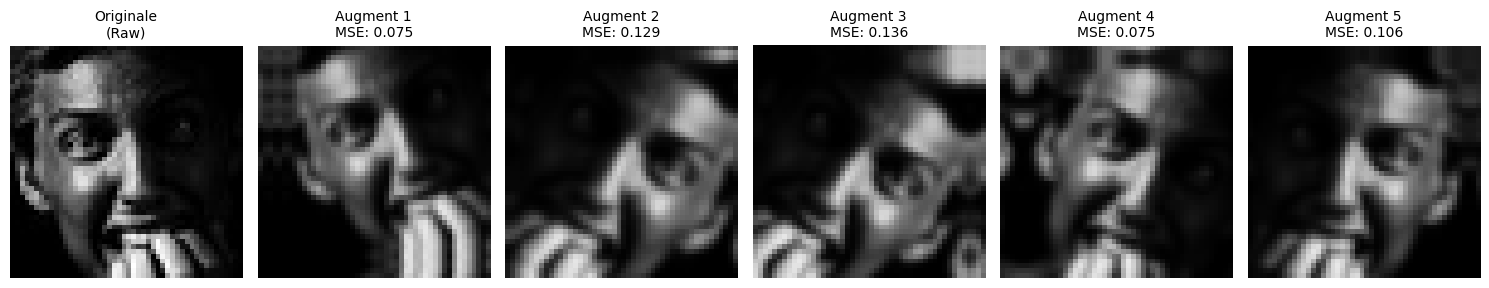

In [5]:
import matplotlib.pyplot as plt
import tensorflow as tf
from typing import List, Dict, Any

def _plot_augmentation_results(img_raw_sq: np.ndarray, augmented_data: List[Dict[str, Any]]) -> None:
    """
    Funzione helper responsabile esclusivamente della renderizzazione 
    grafica dei risultati estratti dalla funzione principale.
    """
    num_samples = len(augmented_data)
    plt.figure(figsize=(15, 3))
    
    # Plot dell'immagine Originale
    plt.subplot(1, num_samples + 1, 1)
    plt.imshow(img_raw_sq, cmap='gray', vmin=0, vmax=255)
    plt.title("Originale\n(Raw)", fontsize=10)
    plt.axis('off')
    
    # Plot delle immagini Aumentate
    for i, data in enumerate(augmented_data):
        plt.subplot(1, num_samples + 1, i + 2)
        plt.imshow(data['image'], cmap='gray', vmin=0.0, vmax=1.0)
        plt.title(f"Augment {i+1}\nMSE: {data['mse']:.3f}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('sanity_check_augmentation.svg', format='svg', bbox_inches='tight')
    plt.show()


def evaluate_augmentation_mathematically(dataset: tf.data.Dataset, aug_model: tf.keras.Sequential, num_samples: int = 5) -> None:
    """
    Estrae un'immagine, calcola le metriche di distorsione tensoriale 
    e delega la visualizzazione al modulo grafico.
    """
    # 1. Estrazione del primo batch
    images, labels = next(iter(dataset.take(1)))
    img_raw = images[0]
    label = labels[0].numpy()
    
    # 2. Normalizzazione
    img_norm = img_raw / 255.0
    
    print(f"--- ANALISI TENSORIALE (Classe: {label}) ---")
    print(f"Originale (Raw)  - Min: {tf.reduce_min(img_raw):.1f}, Max: {tf.reduce_max(img_raw):.1f}")
    print(f"Originale (Norm) - Media: {tf.reduce_mean(img_norm):.4f}, Std: {tf.math.reduce_std(img_norm):.4f}\n")

    # 3. Generazione e calcolo metriche
    augmented_results = []
    
    for i in range(num_samples):
        # Generazione tensore
        aug_batch = aug_model(tf.expand_dims(img_raw, 0), training=True)
        aug_img = aug_batch[0] 
        
        # Calcoli matematici
        aug_mean = tf.reduce_mean(aug_img)
        aug_std = tf.math.reduce_std(aug_img)
        mse = tf.reduce_mean(tf.square(img_norm - aug_img))
        
        print(f"Augment {i+1} - Media: {aug_mean:.4f} | Std (Contrasto): {aug_std:.4f} | MSE: {mse:.4f}")
        
        # Salvataggio dei risultati per il plot successivo
        augmented_results.append({
            'image': tf.squeeze(aug_img).numpy(),
            'mse': mse
        })

    # 4. Delega il rendering grafico alla funzione helper
    _plot_augmentation_results(tf.squeeze(img_raw).numpy(), augmented_results)

# Esecuzione del Sanity Check
evaluate_augmentation_mathematically(train_ds, data_augmentation)

## Conclusioni della Fase 2: Pre-Processing e Validazione (Data-Driven)
Le operazioni svolte in questa fase hanno neutralizzato matematicamente e strutturalmente le criticità emerse durante l'Exploratory Data Analysis, preparando un input robusto per il modello E.R.M.E.S.:

1. **Compensazione dello Sbilanciamento:** L'algoritmo ha calcolato i `class_weights` bilanciati. La Classe 1 (*Disgust*), estremamente rara, ha ricevuto un moltiplicatore di Loss severo ($\approx 9.41$), forzando la rete a generare gradienti ampi per imparare i pattern di questa classe. Al contrario, la Classe 3 (*Happy*) ha ricevuto un peso penalizzante ($\approx 0.57$) per impedire al modello di adagiarsi sulla predizione della classe maggioritaria.
2. **Integrità Strutturale (Sanity Check Tensoriale):** L'analisi sul batch di validazione ha confermato la corretta esecuzione della pipeline:
   * **Normalizzazione:** Il layer di `Rescaling` ha limitato con successo l'intensità dei pixel (es. convertendo il range grezzo [0.0, 255.0] in un tensore normalizzato con media 0.1882).
   * **Stabilità del Contrasto:** Nonostante le trasformazioni spaziali (Zoom, Traslazione, Rotazione), le immagini aumentate mantengono una deviazione standard stabile ($\sigma \approx 0.21 - 0.23$), garantendo la leggibilità dei tratti somatici.
   * **Distorsione Controllata:** La misurazione dell'Errore Quadratico Medio (MSE) tra l'immagine normalizzata e le sue varianti (valori tra **0.07** e **0.14**) dimostra empiricamente l'introduzione di una variabilità spaziale sufficiente a indurre generalizzazione, senza sfociare nella corruzione del dato visivo.

Con la pipeline `tf.data` ottimizzata per l'uso in memoria e matematicamente validata, siamo ufficialmente pronti a procedere con la progettazione e l'addestramento della Rete Neurale Convoluzionale.